## Setup


In [1]:
import os, csv, json
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from transformers import AutoTokenizer

from config import Config
from data.dataset import ScienceQADataset
from models.vqa_model import VQAModel
from visualize.gradcam import (
    gradcam_heatmap, cross_modal_heatmap,
    plot_gradcam_grid, plot_question_conditioned,
    _denormalize, _overlay,
)
from visualize.feature_space import extract_embeddings, cosine_analysis, umap_joint

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
VARIANTS = ["early", "late", "cross_modal"]
os.makedirs("outputs", exist_ok=True)
print(f"Device: {DEVICE}")


/home/pavel/projects/mouse-learning/IAD25-ML-LAB4/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## Load models

In [2]:
def load_model(fusion_type):
    config = Config(fusion_type=fusion_type)
    model  = VQAModel(config).to(DEVICE)
    ckpt   = torch.load(
        f"checkpoints/best_{fusion_type}.pt",
        map_location=DEVICE, weights_only=True,
    )
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, config

models  = {v: load_model(v) for v in VARIANTS}   # {variant: (model, config)}

# Use cross_modal config as the reference (same tokenizer / paths for all)
_, ref_config = models["cross_modal"]
tokenizer = AutoTokenizer.from_pretrained(ref_config.text_model)

val_set  = ScienceQADataset(ref_config.val_parquet,  ref_config, tokenizer, split="val")
test_set = ScienceQADataset(ref_config.test_parquet, ref_config, tokenizer, split="test")
print(f"Val:  {len(val_set)} samples")
print(f"Test: {len(test_set)} samples")


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2148.84it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2095.03it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED

Val:  4241 samples
Test: 4241 samples


## Validation accuracy

In [3]:
@torch.no_grad()
def val_accuracy(model, config):
    loader = DataLoader(
        ScienceQADataset(config.val_parquet, config, tokenizer, split="val"),
        batch_size=64, shuffle=False, num_workers=4,
    )
    correct = total = 0
    for batch in loader:
        logits = model(
            batch["image"].to(DEVICE),
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
            batch["has_image"].to(DEVICE),
            batch["choice_mask"].to(DEVICE),
        )
        correct += (logits.argmax(-1) == batch["answer"].to(DEVICE)).sum().item()
        total   += batch["answer"].size(0)
    return correct / total

results = {}
for v in VARIANTS:
    model, config = models[v]
    acc = val_accuracy(model, config)
    results[v] = {"val_acc": round(acc, 4)}
    print(f"{v:<14}  val_acc={acc:.4f}")


early           val_acc=0.7699
late            val_acc=0.7682
cross_modal     val_acc=0.7701


## GradCAM: feature map visualisation

GradCAM applied to ResNet-50 `layer4` for the cross-modal fusion model. Each row shows the original image, GradCAM heatmap, and overlay.

Saved GradCAM grid → outputs/gradcam_grid.png


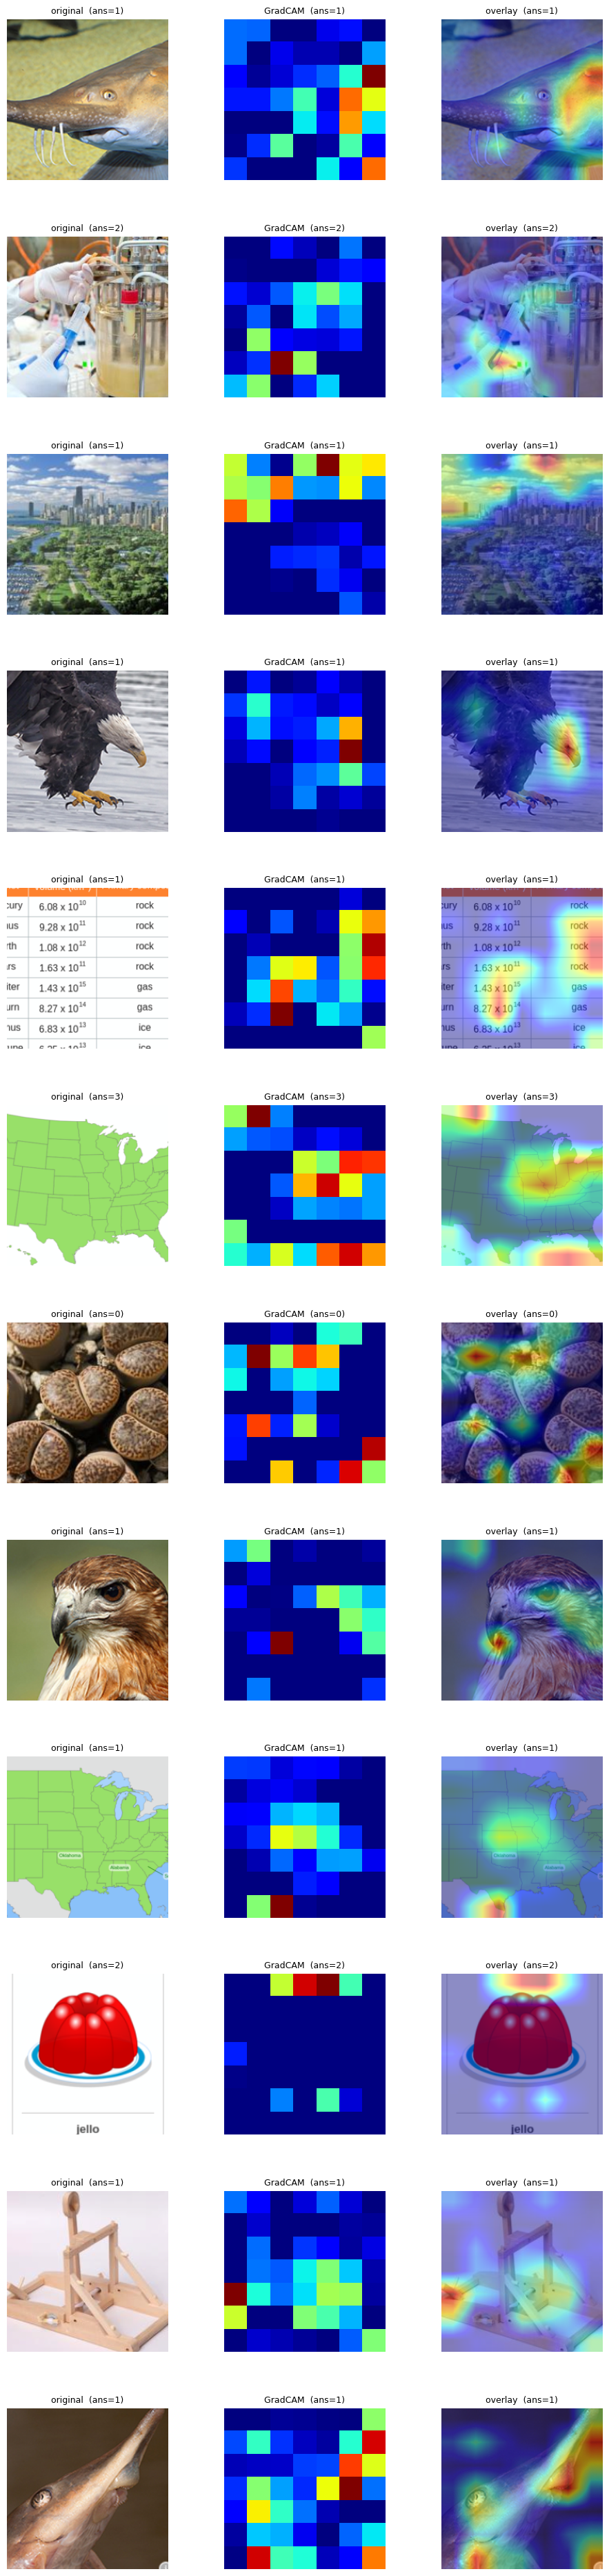

In [4]:
model_cm, config_cm = models["cross_modal"]

# Collect 12 samples that have an image
image_samples = []
for i in range(len(val_set)):
    if val_set.df.iloc[i]["image"] is not None:
        image_samples.append(val_set[i])
    if len(image_samples) == 12:
        break

plot_gradcam_grid(model_cm, image_samples, DEVICE,
                  save_path="outputs/gradcam_grid.png")


## Question-conditioned attention shift

Same image, different questions. Demonstrates the model uses question context to direct spatial attention rather than responding to image saliency unconditionally.

Saved question-conditioned plot → outputs/attention_shift.png


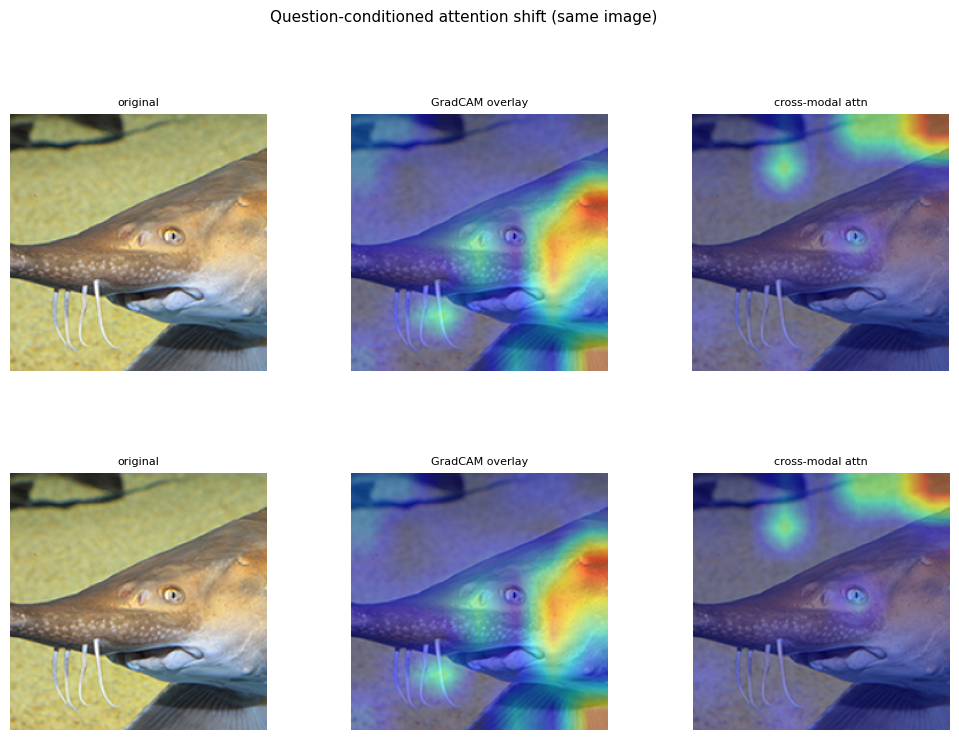

In [ ]:
# Find two val questions that share the same image bytes
# (same topic / consecutive entries often reuse the same image)
shared = []
for i in range(len(val_set) - 1):
    r0 = val_set.df.iloc[i]
    r1 = val_set.df.iloc[i + 1]
    if r0["image"] is not None and r1["image"] is not None:
        b0 = r0["image"].get("bytes", b"")
        b1 = r1["image"].get("bytes", b"")
        if b0 and b0 == b1:
            shared = [val_set[i], val_set[i + 1]]
            break

if not shared:
    # fallback: pick two image-bearing samples from different topics
    shared = [s for s in image_samples if s["has_image"] == 1.0][:2]

plot_question_conditioned(model_cm, shared[0]["image"], shared,
                          DEVICE, save_path="outputs/attention_shift.png")


## Feature space: cosine similarity

Paired (matched image–text) vs. unpaired (random) cosine similarity. A positive delta indicates partial cross-modal alignment.

Extracting embeddings:  48%|████▊     | 32/67 [00:04<00:04,  7.61it/s]


Paired   mean=-0.0167  std=0.0525
Unpaired mean=-0.0177  std=0.0493
Delta (paired - unpaired): +0.0010


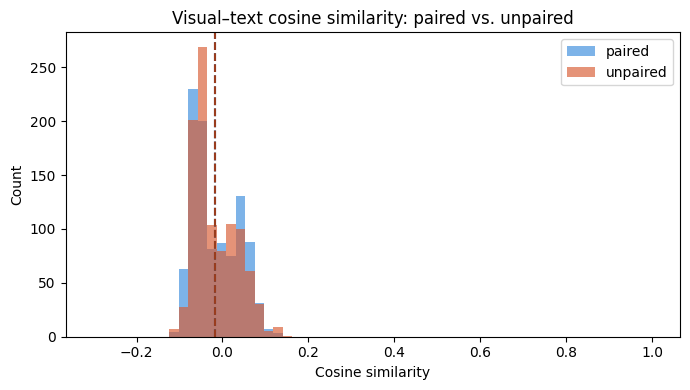

{'paired_mean': -0.016720620833337307,
 'paired_std': 0.052451654168289445,
 'unpaired_mean': -0.01772467937832698,
 'unpaired_std': 0.04928089405375881,
 'delta': 0.0010040585449896736}

In [6]:
val_loader = DataLoader(val_set, batch_size=64, shuffle=False, num_workers=4)
visual_embs, text_embs, subjects = extract_embeddings(
    model_cm, val_loader, DEVICE, max_samples=2000,
)
cosine_stats = cosine_analysis(
    visual_embs, text_embs,
    save_path="outputs/cosine_similarity.png",
)
with open("outputs/cosine_stats.json", "w") as f:
    json.dump(cosine_stats, f, indent=2)
cosine_stats


## Feature space: UMAP joint embedding

Visual and text embeddings projected to 2D. Circle markers = visual, triangle = text. Colour = ScienceQA subject.

Running UMAP …


/home/pavel/projects/mouse-learning/IAD25-ML-LAB4/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


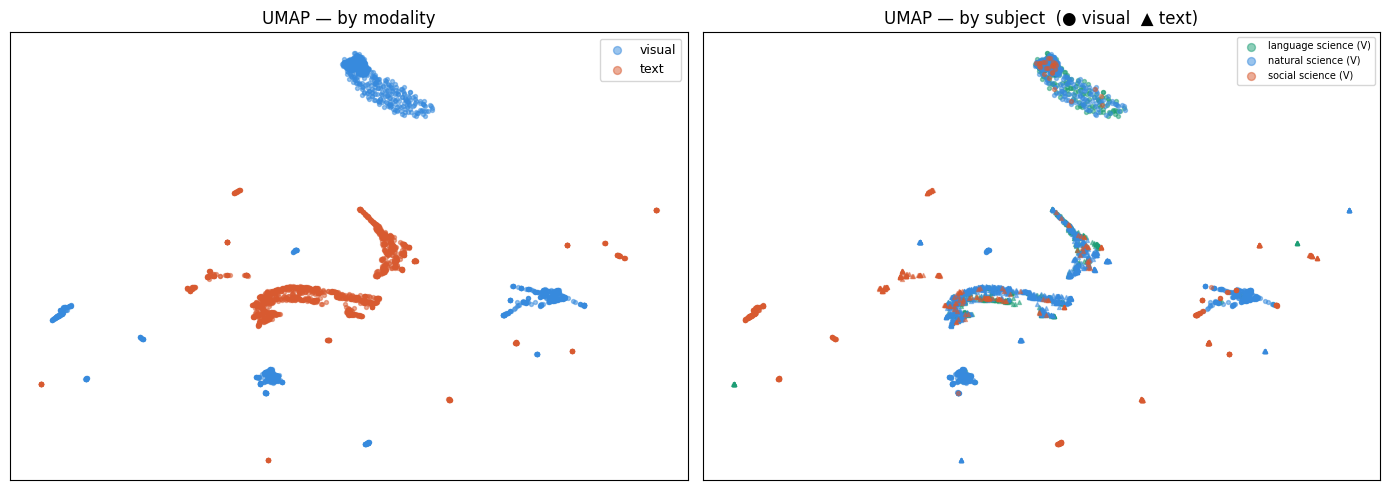

In [7]:
umap_joint(visual_embs, text_embs, subjects,
           save_path="outputs/umap_joint.png")


## Fusion variant comparison

In [8]:
import time

@torch.no_grad()
def benchmark(model, config):
    loader = DataLoader(
        ScienceQADataset(config.val_parquet, config, tokenizer, split="val"),
        batch_size=64, shuffle=False, num_workers=4,
    )
    correct = total = 0
    correct_by_subj = {}
    total_by_subj   = {}
    t0 = time.perf_counter()

    for batch in loader:
        logits = model(
            batch["image"].to(DEVICE),
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
            batch["has_image"].to(DEVICE),
            batch["choice_mask"].to(DEVICE),
        )
        hits = (logits.argmax(-1) == batch["answer"].to(DEVICE)).cpu()
        correct += hits.sum().item()
        total   += batch["answer"].size(0)
        for subj, hit in zip(batch["subject"], hits.tolist()):
            correct_by_subj[subj] = correct_by_subj.get(subj, 0) + int(hit)
            total_by_subj[subj]   = total_by_subj.get(subj, 0) + 1

    elapsed   = time.perf_counter() - t0
    n_params  = sum(p.numel() for p in model.parameters()) / 1e6
    return {
        "val_acc":       round(correct / total, 4),
        "params_M":      round(n_params, 2),
        "ms_per_sample": round(elapsed / total * 1000, 2),
        "subject_acc":   {s: round(correct_by_subj[s] / total_by_subj[s], 4)
                          for s in total_by_subj},
    }

comparison = {v: benchmark(*models[v]) for v in VARIANTS}

# Print table
print(f"{'Fusion':<14} {'Val Acc':>8} {'Params(M)':>10} {'ms/sample':>10}")
print("-" * 48)
for v, r in comparison.items():
    print(f"{v:<14} {r['val_acc']:>8.4f} {r['params_M']:>10.1f} {r['ms_per_sample']:>10.2f}")

subjects = ["natural science", "social science", "language science"]
print(f"\n{'Fusion':<14} " + "  ".join(f"{s[:14]:>14}" for s in subjects))
print("-" * 60)
for v, r in comparison.items():
    row = "  ".join(f"{r['subject_acc'].get(s, float('nan')):>14.4f}" for s in subjects)
    print(f"{v:<14} {row}")

with open("outputs/comparison.json", "w") as f:
    json.dump(comparison, f, indent=2)


Fusion          Val Acc  Params(M)  ms/sample
------------------------------------------------
early            0.7699       92.0       4.32
late             0.7682       91.6       4.38
cross_modal      0.7701       93.9       4.38

Fusion         natural scienc  social science  language scien
------------------------------------------------------------
early                  0.7574          0.8026          0.7714
late                   0.7663          0.7685          0.7724
cross_modal            0.7697          0.7720          0.7695


## Submission CSV

Generates `outputs/submission.csv` using the best-performing fusion variant.

In [9]:
# Select best variant by val accuracy
best_variant = max(comparison, key=lambda v: comparison[v]["val_acc"])
print(f"Best variant: {best_variant}  (val_acc={comparison[best_variant]['val_acc']})")

best_model, best_config = models[best_variant]
test_loader = DataLoader(test_set, batch_size=64, shuffle=False, num_workers=4)

rows = []
with torch.no_grad():
    for batch in test_loader:
        logits = best_model(
            batch["image"].to(DEVICE),
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
            batch["has_image"].to(DEVICE),
            batch["choice_mask"].to(DEVICE),
        )
        preds = logits.argmax(-1).cpu().tolist()
        for tid, pred in zip(batch["task_id"].tolist(), preds):
            rows.append({"ID": int(tid), "answer": pred})

rows.sort(key=lambda r: r["ID"])

out = "outputs/submission.csv"
with open(out, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["ID", "answer"])
    writer.writeheader()
    writer.writerows(rows)

print(f"Saved → {out}  ({len(rows)} rows)")
print("First 5 rows:")
for r in rows[:5]:
    print(f"  {r}")


Best variant: cross_modal  (val_acc=0.7701)
Saved → outputs/submission.csv  (4241 rows)
First 5 rows:
  {'ID': 0, 'answer': 0}
  {'ID': 1, 'answer': 0}
  {'ID': 2, 'answer': 0}
  {'ID': 3, 'answer': 0}
  {'ID': 4, 'answer': 1}
